<a href="https://colab.research.google.com/github/ShanmughapriyaM/Applied-Machine-Learning/blob/main/Unit_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

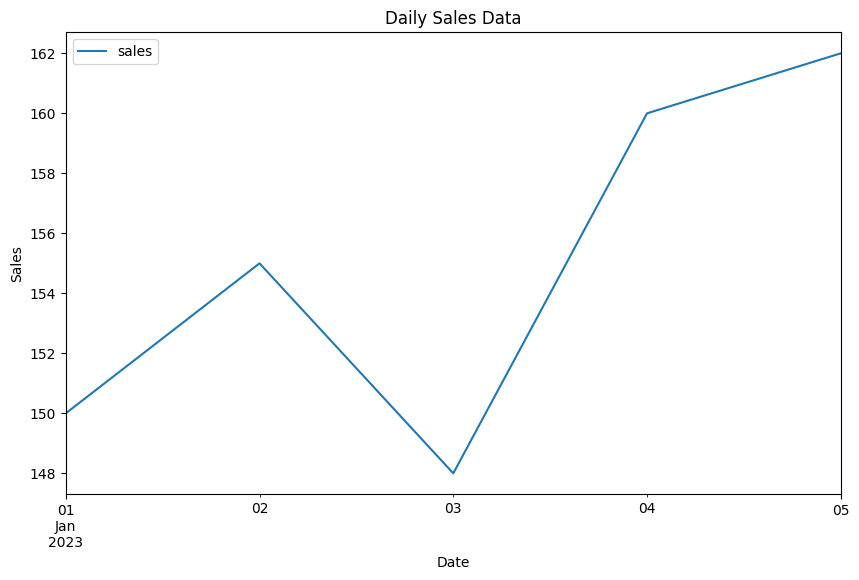

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a sample time series DataFrame
data = {'date': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05']),
        'sales': [150, 155, 148, 160, 162]}
df_ts = pd.DataFrame(data).set_index('date')

# Plot the entire time series
df_ts.plot(figsize=(10, 6))
plt.title('Daily Sales Data')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [ ]:
# Select data from January 2nd to January 4th
subset = df_ts.loc['2023-01-02':'2023-01-04']
print(subset)

            sales
date             
2023-01-02    155
2023-01-03    148
2023-01-04    160


In [ ]:
# Select all data for the month of January 2023
january_data = df_ts.loc['2023-01']
print(january_data)

# Select data for a specific day
specific_day = df_ts.loc['2023-01-03']
print(specific_day)

            sales
date             
2023-01-01    150
2023-01-02    155
2023-01-03    148
2023-01-04    160
2023-01-05    162
sales    148
Name: 2023-01-03 00:00:00, dtype: int64


In [ ]:
# A new DataFrame with hourly data
hourly_data = {'datetime': pd.to_datetime(['2023-01-01 09:00:00', '2023-01-01 10:00:00',
                                         '2023-01-02 11:00:00', '2023-01-02 12:00:00']),
               'traffic': [100, 120, 150, 145]}
df_hourly = pd.DataFrame(hourly_data).set_index('datetime')

# Slice by a specific time range
subset_time = df_hourly.loc['2023-01-01 10:00':'2023-01-02 11:00']
print(subset_time)

                     traffic
datetime                    
2023-01-01 10:00:00      120
2023-01-02 11:00:00      150



Average sales for Jan 1-3: 151.00


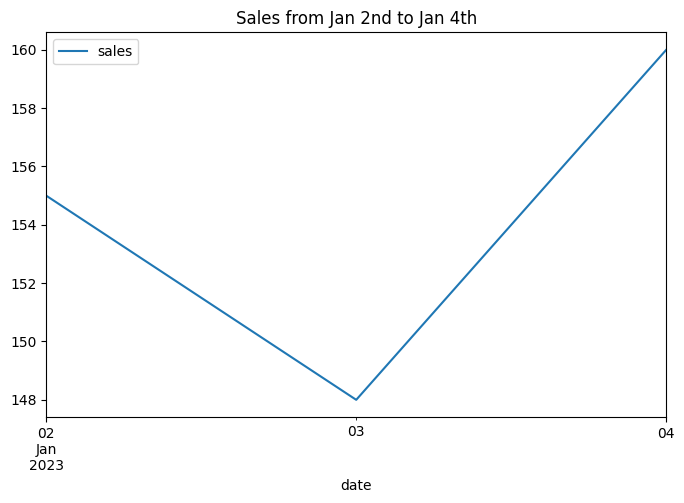

In [ ]:
# Get the average sales for the first three days
subset_avg = df_ts.loc['2023-01-01':'2023-01-03'].mean()
print(f"\nAverage sales for Jan 1-3: {subset_avg['sales']:.2f}")

# Plot the sliced data to visualize a specific period
subset_plot = df_ts.loc['2023-01-02':'2023-01-04']
subset_plot.plot(title='Sales from Jan 2nd to Jan 4th', figsize=(8, 5))
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Create a sample time series DataFrame with daily sales
data = {
    'date': pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05',
                            '2023-01-06', '2023-01-07', '2023-01-08', '2023-01-09', '2023-01-10']),
    'sales': [150, 155, 148, 160, 162, 175, 170, 185, 180, 190]
}
df_ts = pd.DataFrame(data).set_index('date')

# Calculate overall statistics
mean_sales = df_ts['sales'].mean()
median_sales = df_ts['sales'].median()
std_dev_sales = df_ts['sales'].std()
max_sales = df_ts['sales'].max()
min_sales = df_ts['sales'].min()

print("--- Overall Statistics ---")
print(f"Mean Sales: {mean_sales:.2f}")
print(f"Median Sales: {median_sales:.2f}")
print(f"Standard Deviation: {std_dev_sales:.2f}")
print(f"Maximum Sales: {max_sales}")
print(f"Minimum Sales: {min_sales}")


--- Overall Statistics ---
Mean Sales: 167.50
Median Sales: 166.00
Standard Deviation: 14.76
Maximum Sales: 190
Minimum Sales: 148



--- Rolling Statistics ---
            sales  rolling_mean_3_day  rolling_std_5_day
date                                                    
2023-01-01    150                 NaN                NaN
2023-01-02    155                 NaN                NaN
2023-01-03    148          151.000000                NaN
2023-01-04    160          154.333333                NaN
2023-01-05    162          156.666667           6.082763
2023-01-06    175          165.666667           9.974969
2023-01-07    170          169.000000          10.344080
2023-01-08    185          176.666667          10.163661
2023-01-09    180          178.333333           8.905055
2023-01-10    190          185.000000           7.905694


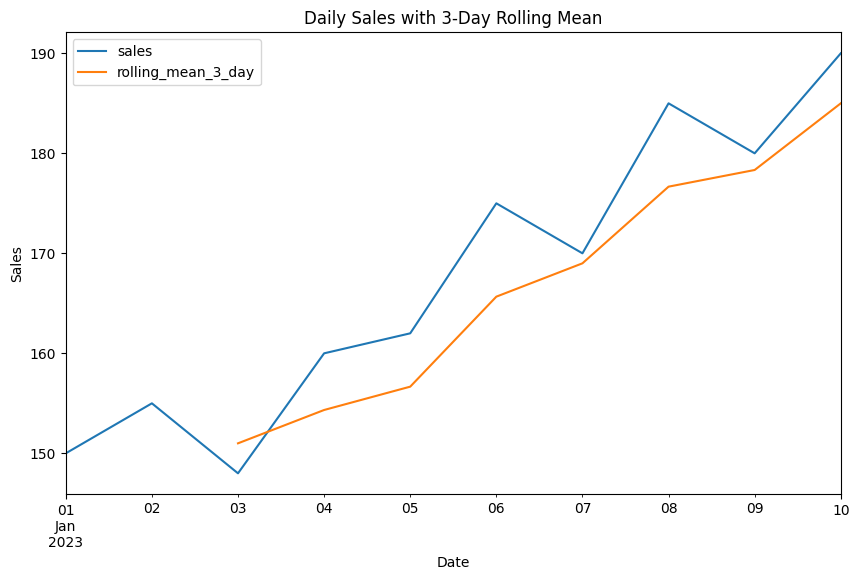

In [ ]:
# Calculate a 3-day rolling mean
df_ts['rolling_mean_3_day'] = df_ts['sales'].rolling(window=3).mean()

# Calculate a 5-day rolling standard deviation
df_ts['rolling_std_5_day'] = df_ts['sales'].rolling(window=5).std()

print("\n--- Rolling Statistics ---")
print(df_ts)

# Plotting the original data and the rolling mean to visualize the trend
df_ts[['sales', 'rolling_mean_3_day']].plot(figsize=(10, 6))
plt.title('Daily Sales with 3-Day Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


In [ ]:
# Resample the daily data to a weekly frequency and calculate the sum of sales
weekly_sales = df_ts['sales'].resample('W').sum()

# Resample the daily data to a weekly frequency and calculate the mean
weekly_mean_sales = df_ts['sales'].resample('W').mean()

# Group sales by month and calculate the sum
monthly_sales = df_ts['sales'].resample('M').sum()

print("\n--- Resampled Weekly Sales (Sum) ---")
print(weekly_sales)

print("\n--- Resampled Weekly Sales (Mean) ---")
print(weekly_mean_sales)



--- Resampled Weekly Sales (Sum) ---
date
2023-01-01     150
2023-01-08    1155
2023-01-15     370
Freq: W-SUN, Name: sales, dtype: int64

--- Resampled Weekly Sales (Mean) ---
date
2023-01-01    150.0
2023-01-08    165.0
2023-01-15    185.0
Freq: W-SUN, Name: sales, dtype: float64


/tmp/ipython-input-988062353.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_ts['sales'].resample('M').sum()


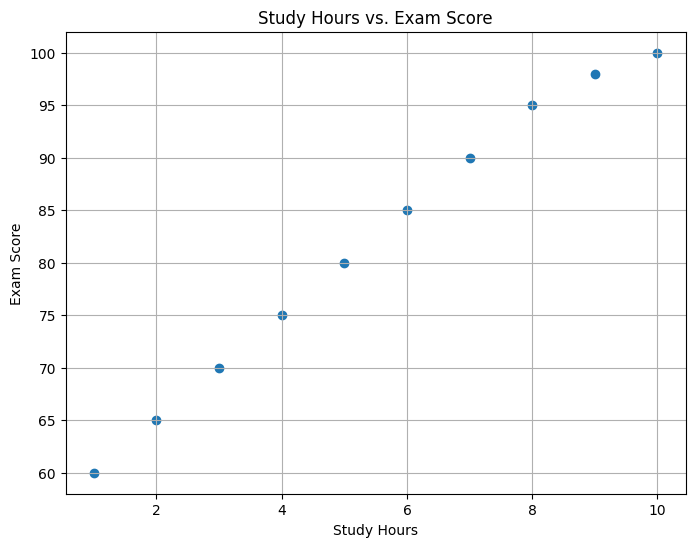

The correlation coefficient is: 1.00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a sample DataFrame with two correlated variables
data = {'study_hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'exam_score': [60, 65, 70, 75, 80, 85, 90, 95, 98, 100]}
df = pd.DataFrame(data)

# Plotting the scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(df['study_hours'], df['exam_score'])
plt.title('Study Hours vs. Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

# Calculating the correlation coefficient
correlation = df['study_hours'].corr(df['exam_score'])
print(f"The correlation coefficient is: {correlation:.2f}")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

<>:21: SyntaxWarning: invalid escape sequence '\c'
<>:21: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipython-input-3690501337.py:21: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel('Average Temperature ($^{\circ}$C)', fontsize=12)


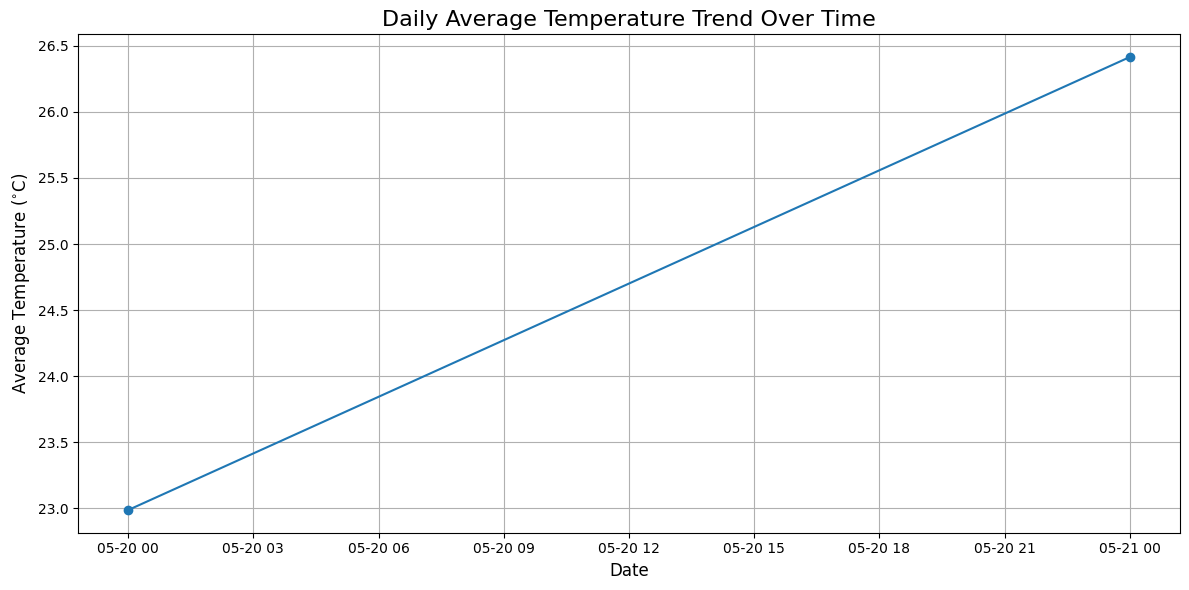

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/Applied ML/dataset.csv")

# Convert the 'Datetime' column to datetime objects
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%a, %d %b %Y %H:%M:%S GMT')

# Set the 'Datetime' column as the index
df.set_index('Datetime', inplace=True)

# Resample the data to a daily frequency and calculate the mean temperature
daily_temp_trend = df['Temperature'].resample('D').mean()

# Plot the trend
plt.figure(figsize=(12, 6))
plt.plot(daily_temp_trend, marker='o', linestyle='-')
plt.title('Daily Average Temperature Trend Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Average Temperature ($^{\circ}$C)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
!pip install hmmlearn
from hmmlearn.hmm import GaussianHMM
import numpy as np
import pandas as pd

# Load your data (Temperature as series)
df = pd.read_csv("/content/drive/MyDrive/Applied ML/dataset.csv")
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()
X = df['Temperature'].values.reshape(-1, 1)

# Fit HMM
model = GaussianHMM(n_components=3, covariance_type="diag", n_iter=200, random_state=42)
model.fit(X)

# Predict states
states = model.predict(X)
print("Sates of the given model")
print(states," ")
# Forecast next 10 steps
last_state = states[-1]
forecast = []
state = last_state

for _ in range(10):
    state = np.random.choice(range(model.n_components), p=model.transmat_[state])
    mean = model.means_[state][0]
    cov = model.covars_[state][0]
    sample = np.random.normal(mean, np.sqrt(cov))
    forecast.append(sample)

print("Forecasted Temperatures:", forecast)


Sates of the given model
[1 0 1 ... 2 2 2]  
Forecasted Temperatures: [array([25.960717]), array([25.53181932]), array([26.32130873]), array([26.37685263]), array([26.35675077]), array([26.4191236]), array([26.68585191]), array([26.32221272]), array([26.03501065]), array([26.08712806])]


In [ ]:
# A simple, fake dataset for Named Entity Recognition (NER)
data = [
    ("Barack Obama was born in Hawaii.",
     [("Barack", "PERSON"), ("Obama", "PERSON"), ("was", "O"), ("born", "O"),
      ("in", "O"), ("Hawaii", "LOCATION"), (".", "O")]),

    ("I am visiting Paris, France.",
     [("I", "O"), ("am", "O"), ("visiting", "O"), ("Paris", "LOCATION"),
      (",", "O"), ("France", "LOCATION"), (".", "O")]),

    ("The CEO, Bill Gates, announced the new project.",
     [("The", "O"), ("CEO", "O"), (",", "O"), ("Bill", "PERSON"), ("Gates", "PERSON"),
      (",", "O"), ("announced", "O"), ("the", "O"), ("new", "O"), ("project", "O"), (".", "O")])
]

# Feature extraction
def word2features(sent, i):
    word = sent[i][0]
    features = {
        'word.lower()': word.lower(),
        'word.isupper()': word.isupper(),
        'word.istitle()': word.istitle(),
        'word.isdigit()': word.isdigit(),
    }
    if i > 0:
        word1 = sent[i-1][0]
        features.update({
            '-1:word.lower()': word1.lower(),
            '-1:word.istitle()': word1.istitle(),
            '-1:word.isupper()': word1.isupper(),
        })
    else:
        features['BOS'] = True

    if i < len(sent)-1:
        word1 = sent[i+1][0]
        features.update({
            '+1:word.lower()': word1.lower(),
            '+1:word.istitle()': word1.istitle(),
            '+1:word.isupper()': word1.isupper(),
        })
    else:
        features['EOS'] = True

    return features

def sent2features(sent):
    return [word2features(sent, i) for i in range(len(sent))]

def sent2labels(sent):
    return [label for token, label in sent]

# FIX: Use the annotated tokens (x), not the raw sentence (s)
X = [sent2features(x) for _, x in data]
y = [sent2labels(x) for _, x in data]

print("Example of features for the word 'Obama':\n", X[0][1])
print("\nExample of labels for the first sentence:\n", y[0])


Example of features for the word 'Obama':
 {'word.lower()': 'obama', 'word.isupper()': False, 'word.istitle()': True, 'word.isdigit()': False, '-1:word.lower()': 'barack', '-1:word.istitle()': True, '-1:word.isupper()': False, '+1:word.lower()': 'was', '+1:word.istitle()': False, '+1:word.isupper()': False}

Example of labels for the first sentence:
 ['PERSON', 'PERSON', 'O', 'O', 'O', 'LOCATION', 'O']


In [ ]:
!pip install sklearn_crfsuite


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.1 MB/s eta 0:00:00


In [ ]:
import sklearn_crfsuite

# Initialize and train the CRF model
crf = sklearn_crfsuite.CRF(
algorithm='lbfgs',
c1=0.1,
c2=0.1,
max_iterations=100,
all_possible_transitions=True
)
crf.fit(X, y)


new_sentence = [("I", "O"), ("met", "O"), ("John", "PERSON"), ("in", "O"), ("New York", "LOCATION"), ("City", "LOCATION")]
new_sentence_features = sent2features(new_sentence)
predictions = crf.predict([new_sentence_features])

print("\nPredicted labels for the new sentence:\n", predictions)




Predicted labels for the new sentence:
 [['O' 'O' 'O' 'O' 'PERSON' 'PERSON']]


In [ ]:
!pip install yfinance hmmlearn scikit-learn numpy pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.3 MB/s eta 0:00:00


/tmp/ipython-input-2389208157.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed


Learned Parameters:
Initial State Probabilities (Start Probabilities): [1.51906210e-11 1.00000000e+00 2.74213004e-12]
Transition Probability Matrix (Transmat):
[[2.34905876e-10 1.00000000e+00 4.14229518e-13]
 [1.67460405e-11 1.00000000e+00 4.81820436e-13]
 [1.07537381e-06 9.99998925e-01 4.23984274e-11]]
Mean of each hidden state (Mean returns):
[[0.01419918]
 [0.0035226 ]
 [0.01405241]]
Variance of each hidden state (Volatility):
[[[1.00000000e+03]]

 [[2.49541006e-04]]

 [[1.00000000e+03]]]




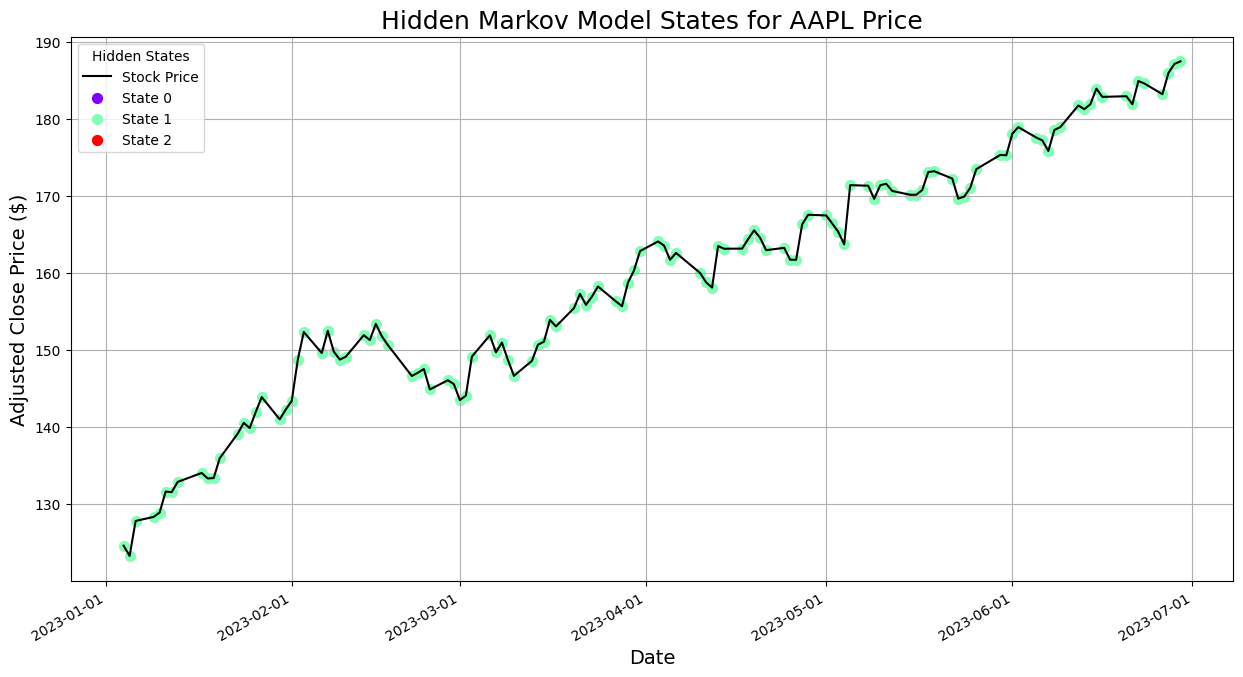

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.cm import rainbow

# 1. Data Acquisition and Preparation
# Sourcing historical data for a specified ticker
# We use 'yfinance' which provides a simple and free way to download data.[1, 2]
# The standard practice for HMMs is to use daily returns rather than raw prices.[3, 4]

# Define the ticker and date range
TICKER = 'AAPL' # Example: Apple Inc.
START_DATE = '2023-01-01'
END_DATE = '2023-06-30' # Approximately 100 trading days

# Download the data
data = yf.download(TICKER, start=START_DATE, end=END_DATE)

# Calculate daily percentage change (returns) which is a common observation for HMMs.[4, 5]
# The `.iloc[1:]` is used to drop the NaN value created by the differencing calculation.
# Correction: Using 'Close' column as it now contains the adjusted price data by default.
returns = data['Close'].pct_change().dropna()

# Prepare data for hmmlearn, which expects a 2D array.[6]
# We reshape the 1D returns series into a column vector.
observations = returns.values.reshape(-1, 1)

# 2. Training the Hidden Markov Model
# We use GaussianHMM for continuous data like returns.[5, 7]
# The choice of hidden states is crucial; we start with a common three-state model
# representing bullish, bearish, and neutral regimes.[3]

# Define the number of hidden states (n_components)
n_states = 3

# Initialize and train the Gaussian HMM.
# The `n_iter` parameter controls the number of iterations for the Baum-Welch algorithm.[6]
model = GaussianHMM(n_components=n_states, n_iter=100, tol=0.01)
model.fit(observations)

# 3. Decoding and Interpretation
# Use the Viterbi algorithm to find the most likely sequence of hidden states.[3, 8]
# The `predict()` method automatically uses the Viterbi algorithm.[6]
hidden_states = model.predict(observations)

# Print the learned parameters for interpretation.[9]
print("Learned Parameters:")
print("Initial State Probabilities (Start Probabilities):", model.startprob_)
print("Transition Probability Matrix (Transmat):")
print(model.transmat_)
print("Mean of each hidden state (Mean returns):")
print(model.means_)
print("Variance of each hidden state (Volatility):")
print(model.covars_)
print("\n")

# 4. Visualization
# Plot the predicted hidden states alongside the stock price data for clear, intuitive insight.[6, 8]
# This helps to visually confirm that the model’s states correspond to actual market behavior.[8]

# Create a figure and axes for the plot
fig, ax = plt.subplots(figsize=(15, 8))

# Define colors for each state
colors = rainbow(np.linspace(0, 1, n_states))

# Get the dates from the DataFrame index
dates = data.index[1:]

# Map each state to a color
state_colors = [colors[state] for state in hidden_states]

# Plot the stock's closing price
ax.plot(dates, data['Close'][1:], color='black', label='Stock Price')

# Iterate through the states and plot colored markers
for i in range(n_states):
    # Find indices where the hidden state is 'i'
    idx = (hidden_states == i)
    ax.scatter(
        dates[idx],
        data['Close'][1:][idx],
        color=colors[i],
        label=f'State {i}',
        s=50, # Marker size
    )

# Format the plot
ax.set_title(f'Hidden Markov Model States for {TICKER} Price', fontsize=18)
ax.set_xlabel('Date', fontsize=14)
ax.set_ylabel('Adjusted Close Price ($)', fontsize=14)
ax.legend(title='Hidden States', loc='best')
ax.grid(True)

# Format the x-axis to show dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gcf().autofmt_xdate()

# Display the plot
plt.show()